# Exercise 1 - Terminology

Describe the following terms with your own words:

***boolean array:***

***broadcasting in numpy:***

***axis in numpy:***

Answer the following questions:

***Show at least three ways to select one or more elements from a Numpy array!***

***What is the difference between Numpy and Scipy?***

In [1]:
### BEGIN SOLUTION

***boolean array:*** a numpy array of datatype bool, which contains True or False values.

***broadcasting in numpy:*** rules how Numpy applies mathematical operators on Numpy arrays of different shapes, i.e. how elementwise operation works between different shapes (e.g. multiplication of a scalar and a vector)

***axis in numpy:*** a dimension of a numpy array, e.g. rows or columns in a 2d-array

Answer the following questions:

***Which ways are there to select one or more elements from a Numpy array?***

 - simple indexing using an integer `a[3]`
 - boolean arrays `a[a < 1]`
 - lists of indexes `a[[1,2,3]]`

***What is the difference between Numpy and Scipy?***

Numpy provides the ndarray data type, Scipy is built on top of Numpy and provides additional functions for calculations.

In [2]:
### END SOLUTION

# Exercise 2 - Frequency of grays

Convert the picture `numpy-meme.png` to gray scale!

Bonus part: Plot a histogram of the brightness of the pixels!

**Instructions:** Load the image by using `plt.imread()`. This will return a three-dimensional array (width, height and colors) with values between zero and one. Using the formula `gray = red * 0.2126 + green * 0.7152 + blue * 0.0722`, convert the picture to shades of gray. Look at the shape of the image and pick the right axis by looking at the length of the array in each axis! You can first calculate a weighted version of the array by multiplying with a vector of length 3 (and the three weights) and then sum along the right axis. Check the shape of the gray image afterwards and plot it using `plt.imshow()` with the parameter `cmap='gray'`. It should be two-dimensional now.

**Bonus part:** Use `image_gray.flatten()` to get all pixels as one-dimensional vector and pass this to the function `plt.hist()` with the parameter `bins=50` to get 50 bins with different gray values.


**Note:** [More information in the Wikipedia](https://en.wikipedia.org/wiki/Grayscale#Converting_color_to_grayscale) about the formula for linear luminance.

In [3]:
# donwload the data
import urllib
import os.path

fname = 'numpy-meme.png'
if not os.path.exists(fname):
    URI = 'https://files.boku.ac.at/filr/public-link/file-download/0d7483c99572915f01958920fa236dd1/18660/7274403103236788681/numpy-meme.png'
    urllib.request.urlretrieve(URI, filename=fname)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (8, 6)  # you can change this to adjust the figure size

In [5]:
### BEGIN SOLUTION

In [6]:
image = plt.imread(fname)

image_gray = (image * [0.2126, 0.7152, 0.0722]).sum(axis=2)

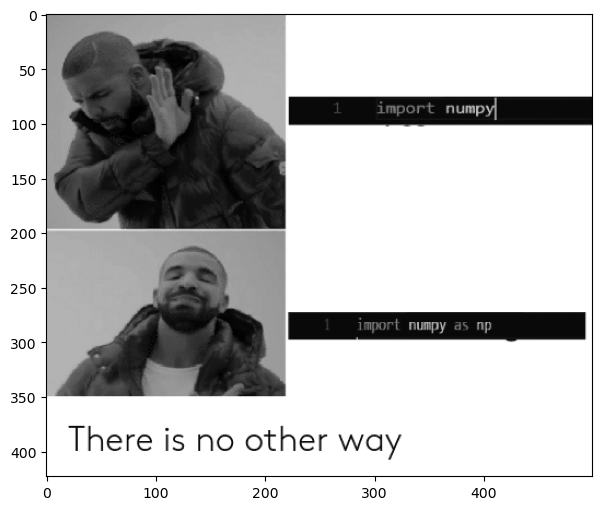

In [7]:
plt.imshow(image_gray, cmap='gray')

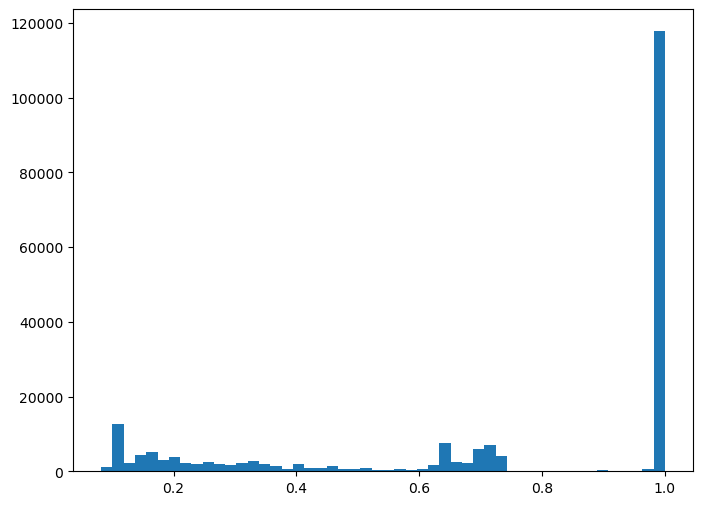

In [8]:
plt.hist(image_gray.flatten(), bins=50);

In [9]:
### END SOLUTION

In [10]:
# # # # # RUN THIS CELL TO CHECK YOUR RESULTS # # # # # 

from urllib.request import urlretrieve
import os.path
if not os.path.exists('check.py'):
    urlretrieve('https://raw.githubusercontent.com/inwe-boku/lecture-scientific-programming/refs/heads/main/check.py', filename='check.py')
from check import check_solution
check_solution([
    ("round(image_gray.sum())", 155296),
], globals())

✅ 1 tests passed. Awesome! 💯


# Exercise 3 - Invasion

Create a numpy array in a variable `canvas` using `np.zeros()` of shape `(8, 11)`. Then set the following elements to one using fancy slicing techniques:

 - Rows 4 and 5 completely.
 - In row 3 all elements except the first one.
 - In row 2 all elements except the first two ones.
 - The two elements defined by: `row_idcs = [0, 1]` and `column_idcs = [2, 3]`
 - In row 6 the elements in column 0 and 2.
 - In row 7 all elements except the first three and the last three.
 
And then afterwards, the following elements to zero:
 - The three elements defined by: `row_idcs= [3, 5, 7]` and `column_idcs = [3, 1, 5]`

As a last step, assign the content of the first five columns to the last five columns in reversed order. This can be done by using a `step=-1` and starting with 4, i.e. the first five columns in reversed order are indexed by `canvas[:, 4::-1]`.

Then plot the canvas using `plt.imshow()` with the parameter `cmap='gray'`!

**Hint:** it helps a lot to have all commands in one cell (including the `imshow()` command) and execute the cell often, to check the result.

**Note:** When ever the instruction says "first element" it is something like `x[0]`, because it refers to the first one in the array. If it is column 1 or row 1 it is `x[1]`, because it refers then to the index of the column/row.

**Note:** It is `canvas[row_index, column_index]`, so if you are thinking in x/y coordinates, it is `canvas[y, x]` and the y axis goes downwards.

In [11]:
### BEGIN SOLUTION

In [12]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

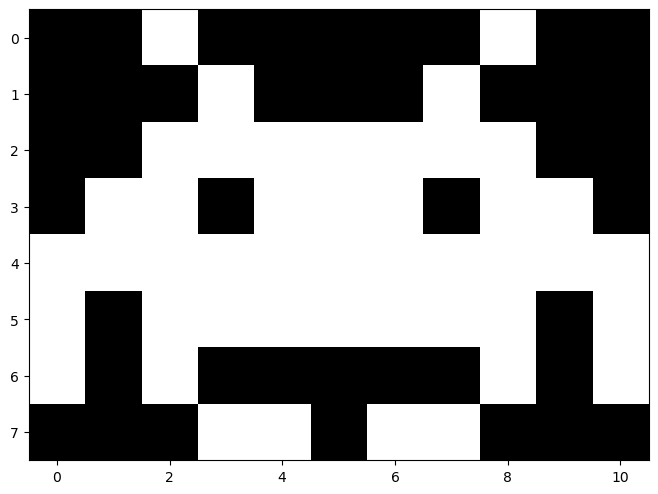

In [13]:
canvas = np.zeros((8, 11))

canvas[4:6, :] = 1
canvas[3, 1:] = 1
canvas[2, 2:] = 1
row_idcs, column_idcs = [0, 1], [2, 3]
canvas[row_idcs, column_idcs] = 1
canvas[6, [0, 2]] = 1
canvas[7, 3:-3] = 1

row_idcs, column_idcs = [3, 5, 7], [3, 1, 5]
canvas[row_idcs, column_idcs] = 0

canvas[:, -5:] = canvas[:, 4::-1]

plt.imshow(canvas, cmap='gray')

In [14]:
### END SOLUTION

In [15]:
# # # # # Run this cell to check your results! A green check mark should appear if everything is correct. # # # # # 

from urllib.request import urlretrieve
import os.path
fname = 'check.py'
if not os.path.exists(fname):
    urlretrieve('https://raw.githubusercontent.com/inwe-boku/lecture-scientific-programming/refs/heads/main/check.py', filename='check.py')
from check import check_solution
check_solution([
    ("np.sum(canvas)", 46),
    ("canvas.diagonal().sum()", 4),
    ("canvas.shape", (8, 11))
], globals())

✅ 3 tests passed. Well done! 🎉


# Exercise 4 - Interpolation

Create a `grid` using `np.linspace()` between 1961 and 1973 with `num=37` points. Then use `interp1d()` from `scipy.interpolate` to interpolate the temperature values on the grid.

Plot the interpolated values and the grid using the parameter `'o-'`. Also plot the original dataset in a second plot and compare the plots.

Read the documentation for `np.interp()` - what is the difference to `scipy.interpolate.interp1d()`?

Note: The parameter 'o-' sets the marker style to _bullet_ and line style to _line_.

<small>Data source: https://www.wien.gv.at/statistik/wetter/</small>

In [16]:
years = [1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973]
mean_temperature_celsius = [10.2, 8.6, 8.7, 9.1, 8.6, 10.1, 10.2, 9.7, 9.2, 9.2, 9.8, 9.3, 9.6]

In [17]:
### BEGIN SOLUTION

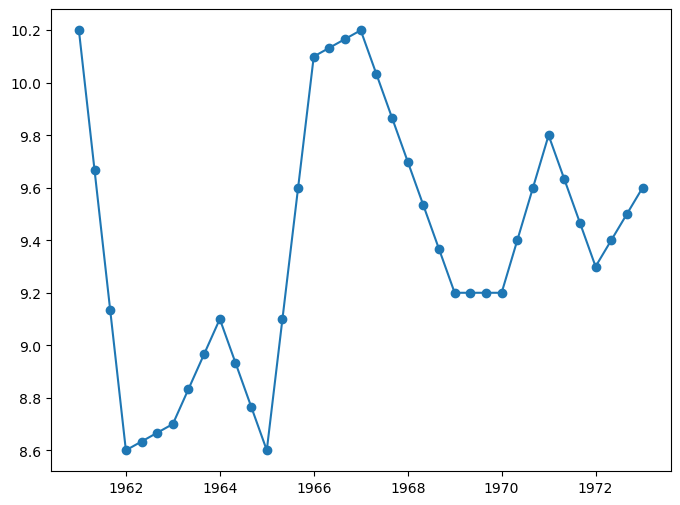

In [18]:
import numpy as np
from scipy.interpolate import interp1d

grid = np.linspace(1961, 1973, num=37)
temperature_interpolated = interp1d(years, mean_temperature_celsius)

plt.plot(grid, temperature_interpolated(grid), 'o-')

In [19]:
### END SOLUTION

# Exercise 5 - Draw a circle (optional bonus exercise, expert level)

Note: to solve this exercise, you will need to work through the bonus material in the second sheet in the notebook for lecture 5. We will probably not have time to discuss this in detail in the lecture.

Draw a full circle: first define a resolution e.g. $N=50$. Then define coordinates $x$ and $y$ using `np.linspace()` and pass the resolution as parameter `num=N`. Use `np.meshgrid()` to define a grid `xx` and `yy`. Define a canvas of shape `(N, N)` using `np.zeros()`. Then use the circle formula $x^2 + y^2 < r^2$ to define all circle points on the grid (use $r=2$). Then use the boolean 2D expression to set the inside of the circle to 1. Finally plot the canvas using `imshow()`.

In [20]:
### BEGIN SOLUTION

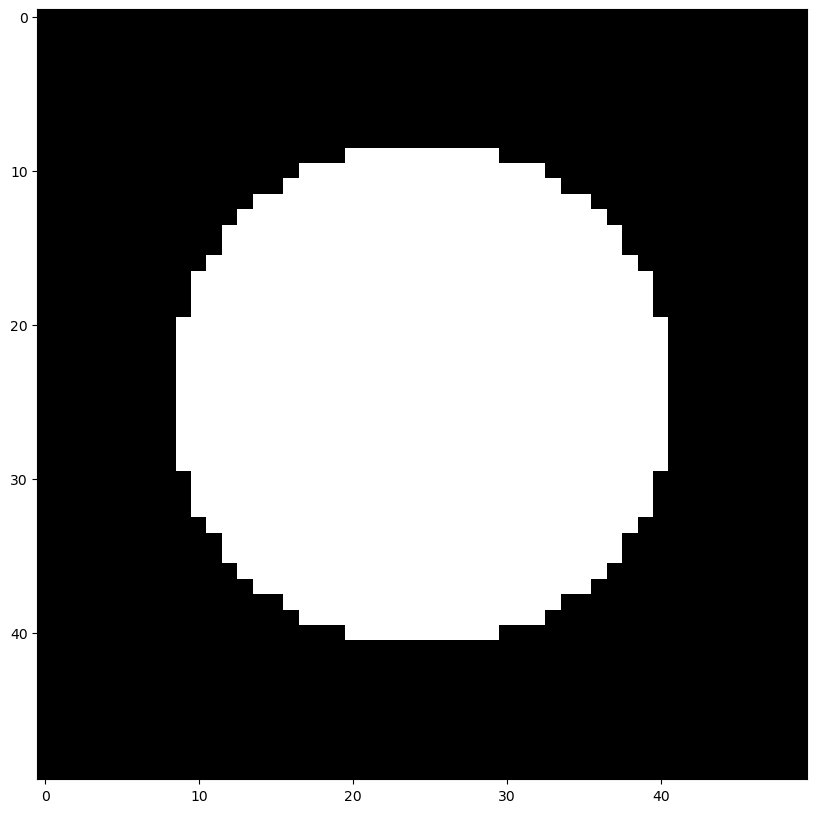

In [21]:

import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rc('figure', figsize=(15, 10))

N = 50
x = np.linspace(-3, 3, num=N)
y = np.linspace(-3, 3, num=N)

xx, yy = np.meshgrid(x, y)

canvas = np.zeros((N, N))

canvas[(xx**2 + yy**2) < 4] = 1

plt.imshow(canvas, cmap='gray')

In [22]:
### END SOLUTION

# Exercise 6 - Count colors (optional bonus exercise, difficult)

Calculate the number of colors used in the picture `numpy-meme.png` and the percentage of the color space (3 x 8bit, i.e. 256 values per color) used!

**Instructions:** Load the image by using `plt.imread()`. This will return a three dimensional array (width, height and colors) with values between zero and one. Multiplying the array with 255 will restore the original 8bit values (integer values between 0 and 255). After multiplying by 255 use `image = image.astype(int)` to convert the image to integer type. Plot the `image` using `plt.imshow()` to see the image and guess the result. Check the shape of the array. One of the axes is of length three - this is the color axis (red, green and blue). We want to map all colors to unique integers. This can be done by defining `colors = red  + green * 256 + blue * 256**2`. This is a unique mapping between the triples `(red, green, blue)` and the integers `color` similar to decimal digits (three values between 0 and 9 e.g. `(3, 5, 1)` can be mapped to a three digit number `3 + 5 * 10 + 1 * 100 = 153`). Then use `np.unique()` to get an array with unique colors (in the mapped form as in `color`). This can be used to determine the number of unique colors in the image. This value can also be used to calculate the percentage of the color space used.

<small>Image source: https://me.me/i/1-import-numpy-1-import-numpy-as-np-there-is-e4a6fb9cf75b413dbb3154794fd3d603</small>

Inspired by [this exercise](https://github.com/rougier/numpy-100/blob/master/100_Numpy_exercises_with_solutions.md#66-considering-a-wh3-image-of-dtypeubyte-compute-the-number-of-unique-colors-) (MIT licensed, [DOI](https://zenodo.org/badge/latestdoi/10173/rougier/numpy-100))

In [23]:
# donwload the data
import urllib
import os.path

fname = 'numpy-meme.png'
if not os.path.exists(fname):
    URI = 'https://files.boku.ac.at/filr/public-link/file-download/0d7483c99572915f01958920fa236dd1/18660/7274403103236788681/numpy-meme.png'
    urllib.request.urlretrieve(URI, filename=fname)

In [24]:
### BEGIN SOLUTION

In [25]:
import numpy as np
import matplotlib.pyplot as plt

In [26]:
image = plt.imread(fname) * 255
image = image.astype(int)

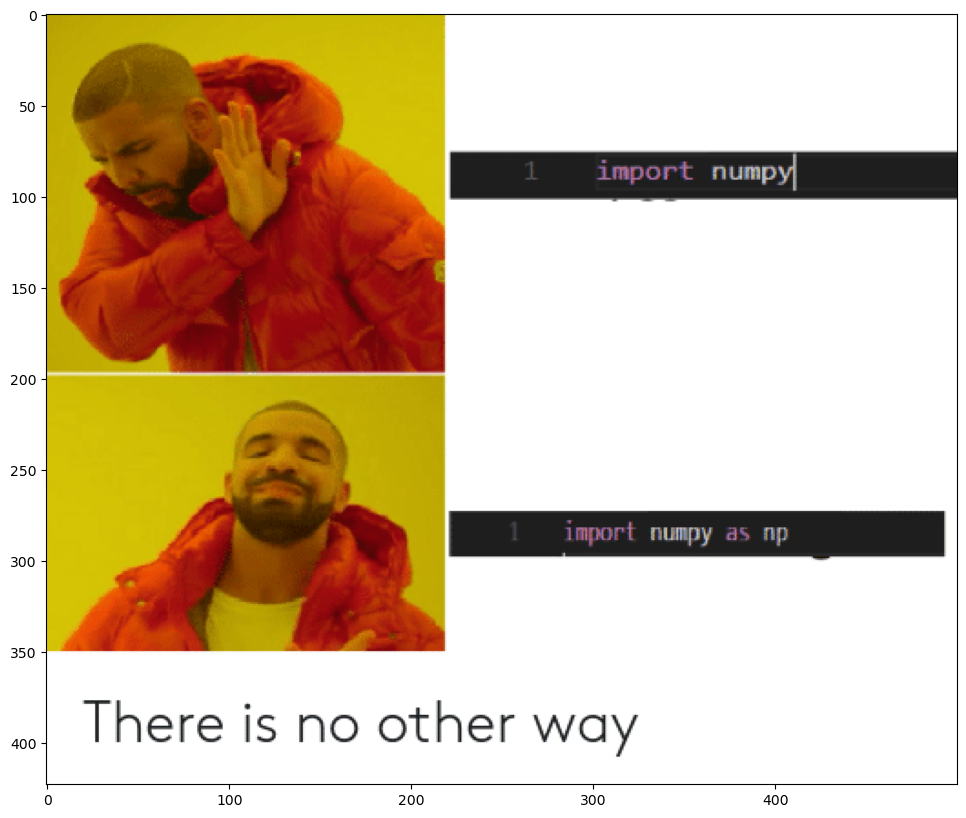

In [27]:
plt.imshow(image)

In [28]:
image.shape

(423, 500, 3)

In [29]:
color = image[:, :, 0] + image[:, :, 1] * 256 + image[:, :, 2] * 256**2

In [30]:
color.shape

(423, 500)

In [31]:
unique_colors_used = len(np.unique(color))
unique_colors_used

258

Percentage of color space used:

In [32]:
share_of_color_space_used = 258/256**3 * 100
share_of_color_space_used

0.0015377998352050781

In [33]:
### END SOLUTION

In [34]:
# # # # # RUN THIS CELL TO CHECK YOUR RESULTS # # # # # 

from urllib.request import urlretrieve
import os.path
if not os.path.exists('check.py'):
    urlretrieve('https://raw.githubusercontent.com/inwe-boku/lecture-scientific-programming/refs/heads/main/check.py', filename='check.py')
from check import check_solution
check_solution([
    ("unique_colors_used", 258),
    ("share_of_color_space_used * 1e3", 1.54)
], globals())

✅ 2 tests passed. Everything correct! 🤓


# Exercise 7 - Create a diagonal matrix  (optional bonus exercise)

Create a matrix `m` with shape `(4, 4)` by using `np.zeros()` and set the 4 diagonal elements to `1` by using indexing using `np.arange()`. Do not use more than three assignment statements in total for this exercise!

Bonus: Find multiple ways to avoid calling `np.arange()` twice and analyze which is the best regarding readability!

Note: Normally you would use `np.diag()` to do this. You can also have a look into the code using `np.diag??`, but it's probably easier to write your own implementation (which might be less generic and slower, but way simpler).

In [35]:
### BEGIN SOLUTION

In [36]:
import numpy as np

In [37]:
m = np.zeros((4,4))

m[np.arange(4), np.arange(4)] = 1
m

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [38]:
# Bonus 1:
m = np.zeros((4,4))
m[(list(range(4)),) * 2] = 1
m

m = np.zeros((4,4))
idcs = np.arange(4)
m[idcs, idcs] = 1
m

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [39]:
# Bonus 2:
m = np.zeros((4,4))
m.flat[::5] = 1
m

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [40]:
# Alternative 1:
np.eye(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [41]:

# Alternative 2:
np.identity(4)

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [42]:
m = np.zeros((4, 4))
np.fill_diagonal(m, 1)
m

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [43]:
### END SOLUTION

In [44]:
# # # # # RUN THIS CELL TO CHECK YOUR RESULTS # # # # # 

from urllib.request import urlretrieve
import os.path
if not os.path.exists('check.py'):
    urlretrieve('https://raw.githubusercontent.com/inwe-boku/lecture-scientific-programming/refs/heads/main/check.py', filename='check.py')
from check import check_solution
check_solution([
    ("np.sum(m)", 4),
    ("m.shape", (4, 4)),
], globals())

✅ 2 tests passed. Everything correct! 🤓
